In [3]:
from pathlib import Path
import json

DATA_NAME = "SLEEP"
DATA_DIR = Path(DATA_NAME)

DATA_INFO_PATH = DATA_DIR / "dataset_info.json"

with open(DATA_INFO_PATH, "r", encoding="utf-8") as f:
    info = json.load(f)

category_list = info["dataset"]["category_list"]
channels = info["dataset"]["channels"]
target_sampling_rate = info["processing"]["target_sampling_rate"]
window_sec = info["processing"]["window_sec"]

print("=== Dataset Intro ===")
print("Categories:", category_list)
print("Channels (count):", len(channels))
print("Channels:", channels)
print("Target Sampling Rate (Hz):", target_sampling_rate)
print("Window Size (sec):", window_sec)

=== Dataset Intro ===
Categories: ['Wake', 'N1', 'N2', 'N3', 'REM']
Channels (count): 6
Channels: ['C3_A2', 'C4_A1', 'F3_A2', 'F4_A1', 'O1_A2', 'O2_A1']
Target Sampling Rate (Hz): 200.0
Window Size (sec): 30.0


## 1) 设定数据路径并检查数据形状
这一格会选择数据集（`DATA_NAME`），并读取 `train/val/test` 的基本信息，先确认维度是否符合预期。


In [4]:
import h5py
import numpy as np

INDEX_PATH_TRAIN = DATA_DIR / "train.h5"
INDEX_PATH_VAL = DATA_DIR / "val.h5"
INDEX_PATH_TEST = DATA_DIR / "test_x_only.h5"

with h5py.File(INDEX_PATH_TRAIN, "r") as f:
    print("keys:", list(f.keys()))
    print("x dtype:", f["X"].dtype)
    print("x shape:", f["X"].shape)
    print("y dtype:", f["y"].dtype)
    print("y shape:", f["y"].shape)
    y = f["y"][()]
    print("unique:", np.unique(y))

keys: ['X', 'y']
x dtype: float32
x shape: (3921, 6, 6000)
y dtype: int64
y shape: (3921,)
unique: [0 1 2 3 4]


## 2) 定义模型：SimpleLinear
最简单的线性分类器，方便和更复杂模型对比。


In [5]:
import torch
import torch.nn as nn

class SimpleLinear(nn.Module):
    def __init__(self, input_channels, time_points, num_classes):
        super(SimpleLinear, self).__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_channels * time_points, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)


## 3) 定义模型：SimpleMLP
把输入拉平后通过多层全连接网络进行分类，表达能力比线性模型更强。


In [6]:
class SimpleMLP(nn.Module):
    def __init__(
        self,
        input_channels,
        num_classes,
        time_points=200,
        hidden_dims=(256, 128),
        dropout=0.3
    ):
        super().__init__()

        input_dim = input_channels * time_points

        layers = []
        prev_dim = input_dim

        for h in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h

        layers.append(nn.Linear(prev_dim, num_classes))

        self.flatten = nn.Flatten()
        self.mlp = nn.Sequential(*layers)

    def forward(self, x):
        # x: (B, C, T)
        x = self.flatten(x)      # -> (B, C*T)
        logits = self.mlp(x)     # -> (B, num_classes)
        return logits

## 4) 定义模型：EEGNet
EEGNet 的本质是一个“结构上受约束的 CNN”，通过“时间卷积 + 空间卷积（depthwise）+ 可分离卷积（separable）”分阶段提取 EEG 的时域、频域和空间特征。

卷积结构版本，利用时序与通道方向的局部模式，适合 EEG 信号特征提取。常用于作为baseline


In [13]:
class EEGNet(nn.Module):  # EEGNet-8,2
    def __init__(self, chans,time_point=200,f1=8, d=2, pk1=4, pk2=8, dp=0.5, max_norm1=1,norm=torch.nn.Identity()):
        super(EEGNet, self).__init__()
        f2 = f1 * d
        self.block1 = nn.Sequential(
            nn.Conv2d(1, f1, (1, 64), padding=(0,32), bias=False),
            nn.BatchNorm2d(f1),
        )
        # Spatial Filters
        self.block2 = nn.Sequential(
            nn.Conv2d(f1, d * f1, (chans, 1), groups=f1, bias=False),  # Depthwise Conv
            nn.BatchNorm2d(d * f1),
            nn.ELU(),
            nn.AvgPool2d((1, pk1), stride=pk1),
            nn.Dropout(dp)
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(d * f1, f2, (1, 16), groups=f2, bias=False, padding=(0,8)),  # Separable Conv
            nn.Conv2d(f2, f2, kernel_size=1, bias=False),  # Pointwise Conv
            nn.BatchNorm2d(f2),
            nn.ELU(),
            nn.AvgPool2d((1, pk2), stride=pk2),
            nn.Dropout(dp)
        )

        self._apply_max_norm(self.block2[0], max_norm1)
        self.embed_dim = f2 * ((time_point // pk1) // pk2)
        self.norm=norm


    def _apply_max_norm(self, layer, max_norm):
        for name, param in layer.named_parameters():
            if 'weight' in name:
                param.data = torch.renorm(param.data, p=2, dim=0, maxnorm=max_norm)

    def forward(self, x):
        self.norm(x)
        if len(x.shape) == 2:
            x = x.unsqueeze(dim=1)
        x = self.block1(x.unsqueeze(dim=1))
        x = self.block2(x)
        x = self.block3(x)
        return x.flatten(start_dim=1)

## 5) 导入模型：EEGGRU
这里希望同学们自己手搓一个RNN代码，试试RNN的训练效果如何


In [2]:
from RNN_Exercise import ExerciseEEGLSTM

## 6) 准备 DataLoader 并训练/验证
这一格完成数据加载、损失函数与优化器设置，然后执行训练循环并记录 `train/val` 指标与曲线。


加载数据...
数据形状: torch.Size([3921, 6, 1000])
参数量: 19,685

训练 500 epochs...

Epoch   1/500 | Train Loss: 1.6099 | Val Loss: 1.6120 | Val Acc: 0.2545
Epoch  10/500 | Train Loss: 1.5681 | Val Loss: 1.5591 | Val Acc: 0.2906
Epoch  20/500 | Train Loss: 1.4214 | Val Loss: 1.4034 | Val Acc: 0.3462
Epoch  30/500 | Train Loss: 1.3232 | Val Loss: 1.3089 | Val Acc: 0.4158
Epoch  40/500 | Train Loss: 1.2439 | Val Loss: 1.2262 | Val Acc: 0.4601
Epoch  50/500 | Train Loss: 1.1771 | Val Loss: 1.2147 | Val Acc: 0.4843
Epoch  60/500 | Train Loss: 1.1265 | Val Loss: 1.1267 | Val Acc: 0.5281
Epoch  70/500 | Train Loss: 1.1094 | Val Loss: 1.0703 | Val Acc: 0.5348
Epoch  80/500 | Train Loss: 1.0602 | Val Loss: 1.0500 | Val Acc: 0.5564
Epoch  90/500 | Train Loss: 1.0317 | Val Loss: 1.0801 | Val Acc: 0.5492
Epoch 100/500 | Train Loss: 1.0181 | Val Loss: 0.9869 | Val Acc: 0.5956
Epoch 110/500 | Train Loss: 1.0019 | Val Loss: 1.0013 | Val Acc: 0.5873
Epoch 120/500 | Train Loss: 0.9801 | Val Loss: 1.0684 | Val Acc

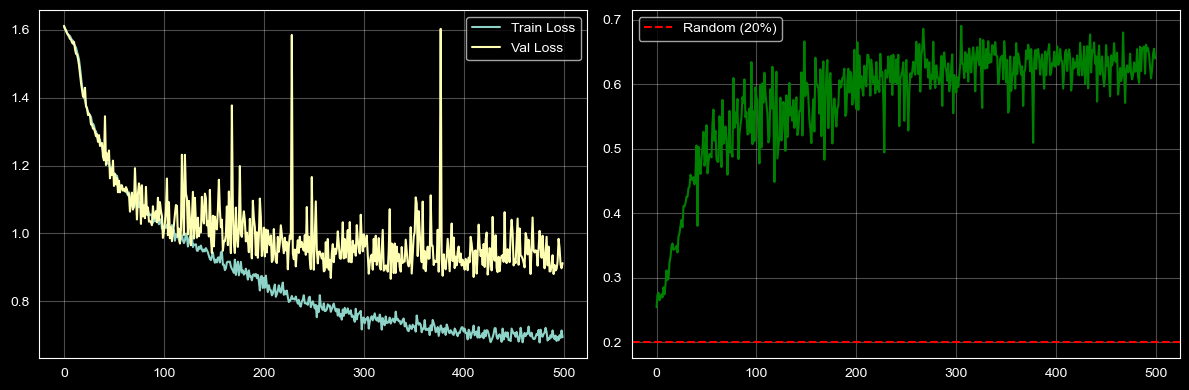

加载数据...
数据形状: torch.Size([3921, 6, 1000])
参数量: 19,685

训练 500 epochs...

Epoch   1/500 | Train Loss: 1.6157 | Val Loss: 1.6060 | Val Acc: 0.2148
Epoch  10/500 | Train Loss: 1.5521 | Val Loss: 1.5435 | Val Acc: 0.3426
Epoch  20/500 | Train Loss: 1.3964 | Val Loss: 1.3918 | Val Acc: 0.3498
Epoch  30/500 | Train Loss: 1.3118 | Val Loss: 1.2994 | Val Acc: 0.4168
Epoch  40/500 | Train Loss: 1.2105 | Val Loss: 1.2095 | Val Acc: 0.4621
Epoch  50/500 | Train Loss: 1.1689 | Val Loss: 1.1611 | Val Acc: 0.5451
Epoch  60/500 | Train Loss: 1.1146 | Val Loss: 1.0991 | Val Acc: 0.5137


In [7]:
import h5py
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from torch.utils.data import DataLoader
from TEST_DATASET import TrainDataset, TestDataset
from sklearn.utils.class_weight import compute_class_weight

# 参数
CHANNELS = 6
CLASSES = 5
BATCH_SIZE = 64
EPOCHS = 500
LR = 1e-3

# 数据加载与降采样
def downsample(data, target_len=1000):
    step = data.shape[-1] // target_len
    return data[:, :, ::step]

print("加载数据...")
train_ds = TrainDataset(INDEX_PATH_TRAIN)
val_ds = TrainDataset(INDEX_PATH_VAL)
test_ds = TestDataset(INDEX_PATH_TEST)

train_ds.x = downsample(train_ds.x, 1000)
val_ds.x = downsample(val_ds.x, 1000)
print(f"数据形状: {train_ds.x.shape}")

# 类别权重
y_train = train_ds.y.numpy()
class_weights = torch.tensor(
    compute_class_weight('balanced', classes=np.unique(y_train), y=y_train),
    dtype=torch.float32
)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)


# 精简版EEGNet
class EEGNet(nn.Module):
    def __init__(self, chans=6, time_points=1000, num_classes=5):
        super().__init__()
        # 时间卷积
        self.conv1 = nn.Sequential(
            nn.Conv2d(1, 16, (1, 64), padding=(0, 32), bias=False),
            nn.BatchNorm2d(16), nn.ELU(), nn.AvgPool2d((1, 2))
        )
        # 空间卷积 (深度可分离)
        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, (chans, 1), groups=16, bias=False),
            nn.BatchNorm2d(32), nn.ELU(), nn.AvgPool2d((1, 2)), nn.Dropout(0.3)
        )
        # 可分离卷积
        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 32, (1, 16), groups=32, padding=(0, 8), bias=False),
            nn.Conv2d(32, 32, 1, bias=False),
            nn.BatchNorm2d(32), nn.ELU(), nn.AdaptiveAvgPool2d((1, 8)), nn.Dropout(0.3)
        )
        self.classifier = nn.Sequential(
            nn.Linear(32 * 8, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = x.unsqueeze(1)  # (B,C,T) -> (B,1,C,T)
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        return self.classifier(x.flatten(1))


model = EEGNet(chans=CHANNELS, num_classes=CLASSES)
print(f"参数量: {sum(p.numel() for p in model.parameters()):,}")

criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=LR, epochs=EPOCHS, steps_per_epoch=len(train_loader), pct_start=0.3
)

# 训练
train_losses, val_losses, val_accs = [], [], []
best_acc = 0

print(f"\n训练 {EPOCHS} epochs...\n")
for epoch in range(EPOCHS):
    model.train()
    train_loss, train_correct, train_n = 0, 0, 0
    for x, y in train_loader:
        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        train_loss += loss.item() * len(y)
        train_n += len(y)
        train_correct += (out.argmax(1) == y).sum().item()

    model.eval()
    val_loss, val_correct, val_n = 0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            out = model(x)
            loss = criterion(out, y)
            val_loss += loss.item() * len(y)
            val_n += len(y)
            val_correct += (out.argmax(1) == y).sum().item()

    train_losses.append(train_loss / train_n)
    val_losses.append(val_loss / val_n)
    val_acc = val_correct / val_n
    val_accs.append(val_acc)

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), f'{DATA_NAME}/best_model.pth')

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_losses[-1]:.4f} | "
              f"Val Loss: {val_losses[-1]:.4f} | "
              f"Val Acc: {val_acc:.4f}")

print(f"\n最佳验证准确率: {best_acc:.4f}")

# 加载最佳模型
model.load_state_dict(torch.load(f'{DATA_NAME}/best_model.pth'))

# 画图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(train_losses, label='Train Loss')
ax1.plot(val_losses, label='Val Loss')
ax1.legend(), ax1.grid(True, alpha=0.3)
ax2.plot(val_accs, color='green')
ax2.axhline(y=0.2, color='red', linestyle='--', label='Random (20%)')
ax2.legend(), ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



## 7) 生成并保存 test 预测标签
使用当前训练好的 `model` 在测试集推理，把预测类别按“每行一个数字”写入文本文件。


In [7]:
# -------------------------
# 保存 test 预测标签（每行一个数字）
# -------------------------
model.eval()
output_path = f'{DATA_NAME}/{DATA_NAME}.txt'

all_test_labels = []
with torch.no_grad():
    for test_data in test_loader:  # test_loader 已经是 shuffle=False
        test_output = model(test_data)
        test_pred = torch.argmax(test_output, dim=1)
        all_test_labels.extend(test_pred.cpu().tolist())

with open(output_path, "w", encoding="utf-8") as f:
    for label in all_test_labels:
        f.write(f"{int(label)}\n")

print(f"Saved {len(all_test_labels)} labels to: {output_path}")

NameError: name 'model' is not defined